In [2]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
import os
import pandas as pd
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, RocCurveDisplay
import seaborn as sns


# parameters to perform STFT and keypoint detection
n_fft = 512
hop_length = 160
beta_a = 0.15  # Absolute threshold...higher values will yield fewer keypoints
beta_r = 0.85  # Relative threshold...higher values will yield fewer keypoints
dt, df = 4, 4  # Neighborhood size
sr = 22050
eps = 1e-4


def stft(y, sr, n_fft, hop_length, eps):
    """
        S = |STFT(y)|^2 eta power spectrogram
        log_S = log(S + eps) - log(eps) ekhane eps ekta chhoto value jate log(0) na hoy, log scale e neya hocche
        log_S = (log_S - min(log_S)) / (max(log_S) - min(log_S)) ekhane log_S ke normalize kora hocche
        eta return shape hibe (n_bins, n_frames) jekhane n_bins = n_fft // 2 + 1 and n_frames = len(y) // hop_length + 1
        ekhane n_bins holo frequency bins and n_frames holo time frames kintu actual time ar freqs onno dimension e hobe
    """
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length)) ** 2
    # print(f"STFT shape: {S.shape}, min: {np.min(S)}, max: {np.max(S)}")
    log_S = np.log(S + eps) - np.log(eps)
    log_S = (log_S - np.min(log_S)) / (np.max(log_S) - np.min(log_S))
    # print(f"Log-scaled STFT shape: {log_S.shape}, min: {np.min(log_S)}, max: {np.max(log_S)}")
    return log_S

def calc_keypoints(log_S, dt, df, beta_a, beta_r):

    local_max_time = maximum_filter(log_S, size=(1, 2 * dt + 1)) == log_S
    local_max_freq = maximum_filter(log_S, size=(2 * df + 1, 1)) == log_S
    keypoints = np.logical_or(local_max_time, local_max_freq)
    
    abs_mask = log_S >= beta_a
    background_mean = maximum_filter(log_S, size=(2 * df + 1, 2 * dt + 1))
    rel_mask = log_S >= beta_r * background_mean
    
    final_mask = keypoints & abs_mask & rel_mask
    return final_mask

def plotter(log_S, mask, sr, hop_length, save_path=None, filename=None, plot=True):

    freq_bins, time_bins = np.where(mask)
    times = time_bins * hop_length / sr
    freqs = freq_bins * (sr / 2) / log_S.shape[0]
    
    if plot:
        # Dual plot - STFT and keypoints
        fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
        # Plot 1: STFT
        img = librosa.display.specshow(
            log_S, sr=sr, hop_length=hop_length, x_axis="time", y_axis="linear", ax=axs[0]
        )
        axs[0].set_title("Log-Scaled STFT Spectrogram")
        fig.colorbar(img, ax=axs[0], format="%+2.0f")
        # Plot 2: Key-points only

        axs[1].scatter(times, freqs, color="red", s=10, label="Key-Points")
        axs[1].set_title("Key-Points Only")
        axs[1].set_ylabel("Frequency (Hz)")
        axs[1].set_xlabel("Time (s)")
        axs[1].legend()
        axs[1].set_ylim(0, sr // 2)
        plt.tight_layout()

        plt.tight_layout()
        plt.savefig("./test.png", dpi=150, bbox_inches='tight', pad_inches=0)
        plt.show()
    
    return times, freqs, freq_bins, time_bins


In [3]:


def process_audio(audio_path, save_path=None, filename=None, plot=True):
    """Process a single audio file through the full pipeline."""
    try:
        
        y, loaded_sr = librosa.load(audio_path, sr=sr, res_type="kaiser_fast")
        
        log_S = stft(y, loaded_sr, n_fft=n_fft, hop_length=hop_length, eps=eps)
        
        kp_mask = calc_keypoints(log_S, dt, df, beta_a, beta_r)
        
        times, freqs, freq_bins, time_bins = plotter(
            log_S, kp_mask, sr, hop_length, save_path, filename, plot
        )
        
        return {
            'times': times,
            'freqs': freqs,
            'freq_bins': freq_bins,
            'time_bins': time_bins,
            'log_S': log_S,
            'kp_mask': kp_mask
        }
    except Exception as e:
        print(f"Error processing {audio_path}: {str(e)}")
        return None



In [5]:
# load all datasets and process
dataset_path = "/media/arafat/New Volume/UrbanSound8K/UrbanSound8K/audio/"  
output_path = "./data/urban8k_stft_keypoints/"
 
# load all the sub directories in dataset_path
# sub_dirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]
# # sub_dirs = sub_dirs[:2]  # Limit to first 10 subdirectories for testing
# # print(sub_dirs)

# # load all the audio files in each sub directory, process for each sub directory and save the results in the output_path following the structure of the dataset_path
# for sub_dir in sub_dirs:
#     sub_dir_path = os.path.join(dataset_path, sub_dir)
#     output_sub_dir = os.path.join(output_path, sub_dir)
#     Path(output_sub_dir).mkdir(parents=True, exist_ok=True)
    
#     audio_files = [f for f in os.listdir(sub_dir_path) if f.endswith('.wav')]
    
#     for audio_file in audio_files:
#         audio_path = os.path.join(sub_dir_path, audio_file)
#         print(f"Processing {audio_file} in {sub_dir}...")
#         result = process_audio(audio_path, save_path=output_sub_dir, filename=audio_file, plot=False)
        
#         if result is not None:
#             # Save the results as a numpy file
#             np.save(os.path.join(output_sub_dir, f"{audio_file[:-4]}_keypoints.npy"), result)
#         else:
#             print(f"Failed to process {audio_file} in {sub_dir}.")
# # Print completion message
# print("Processing complete. All keypoints saved in the specified output directory.")



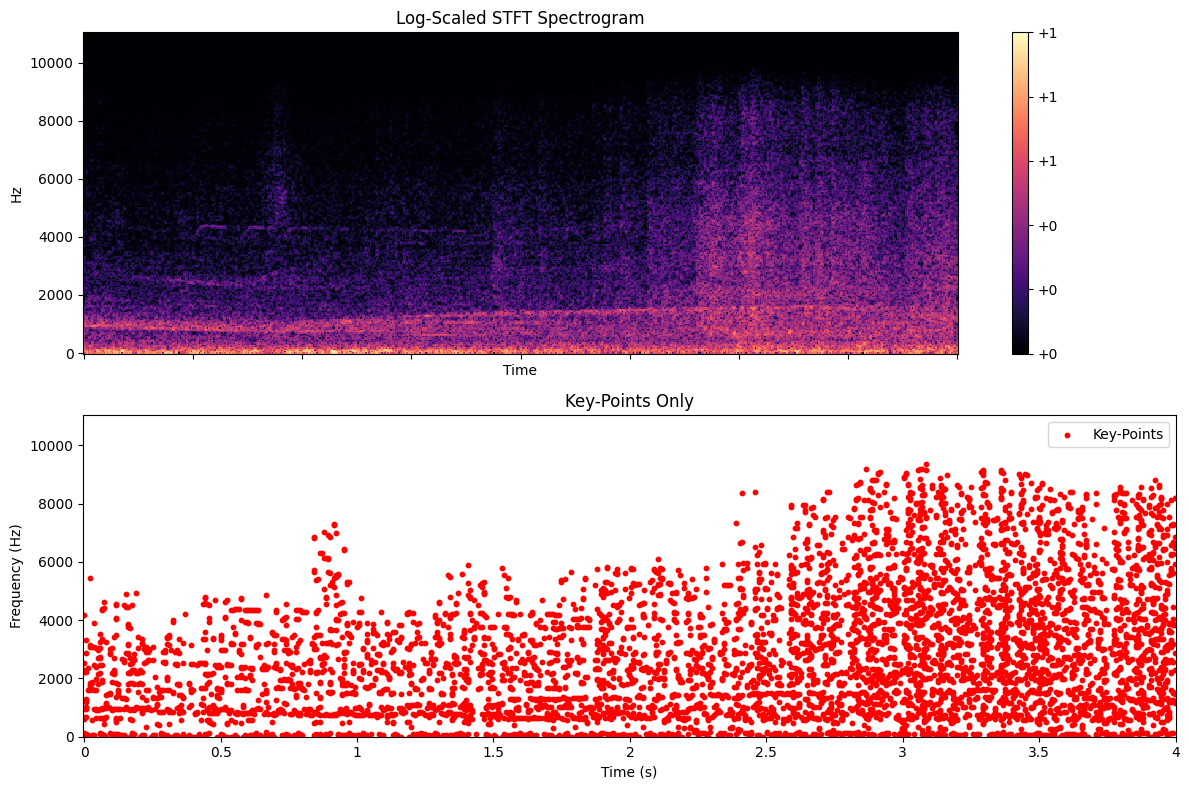

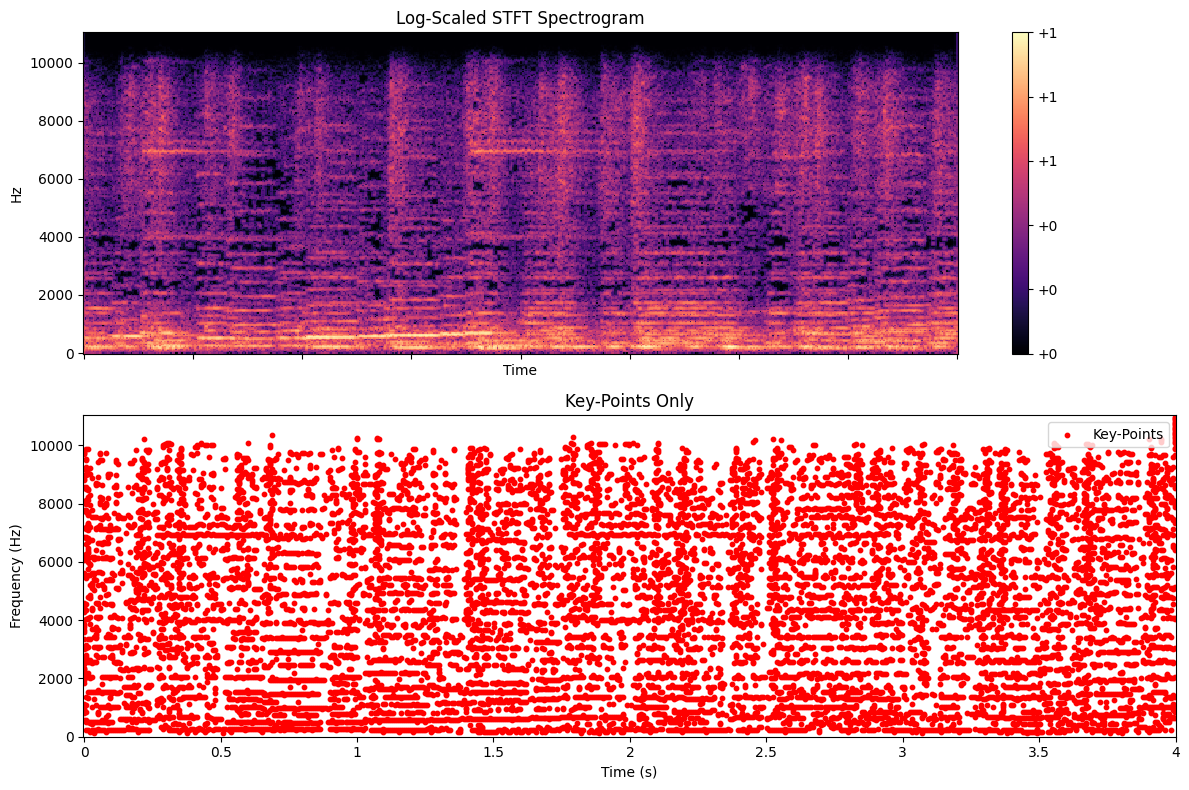

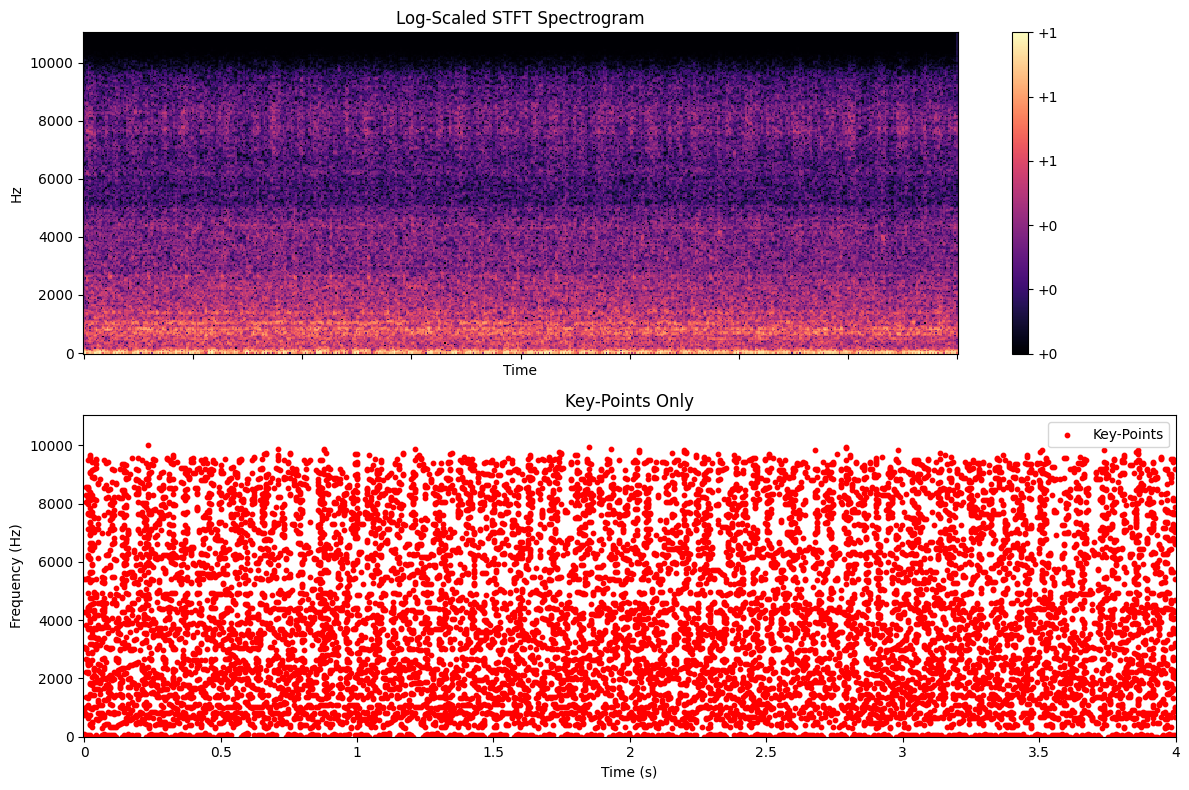

(257, 552)
(257, 552)
(257, 552)


In [ ]:

result2= process_audio(f"{dataset_path}fold7/28385-9-0-44.wav", plot=True)
result3= process_audio(f"{dataset_path}fold10/15544-5-0-7.wav", plot=True)

print(result['log_S'].shape)
print(result2['log_S'].shape)
print(result3['log_S'].shape)


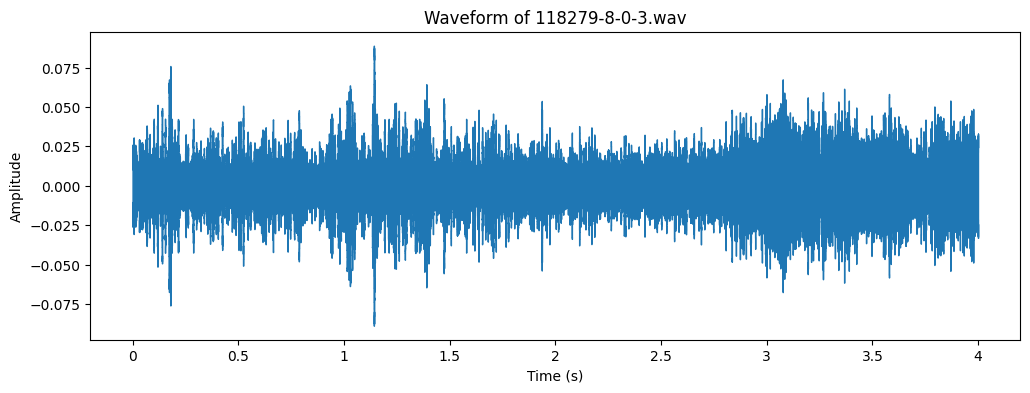

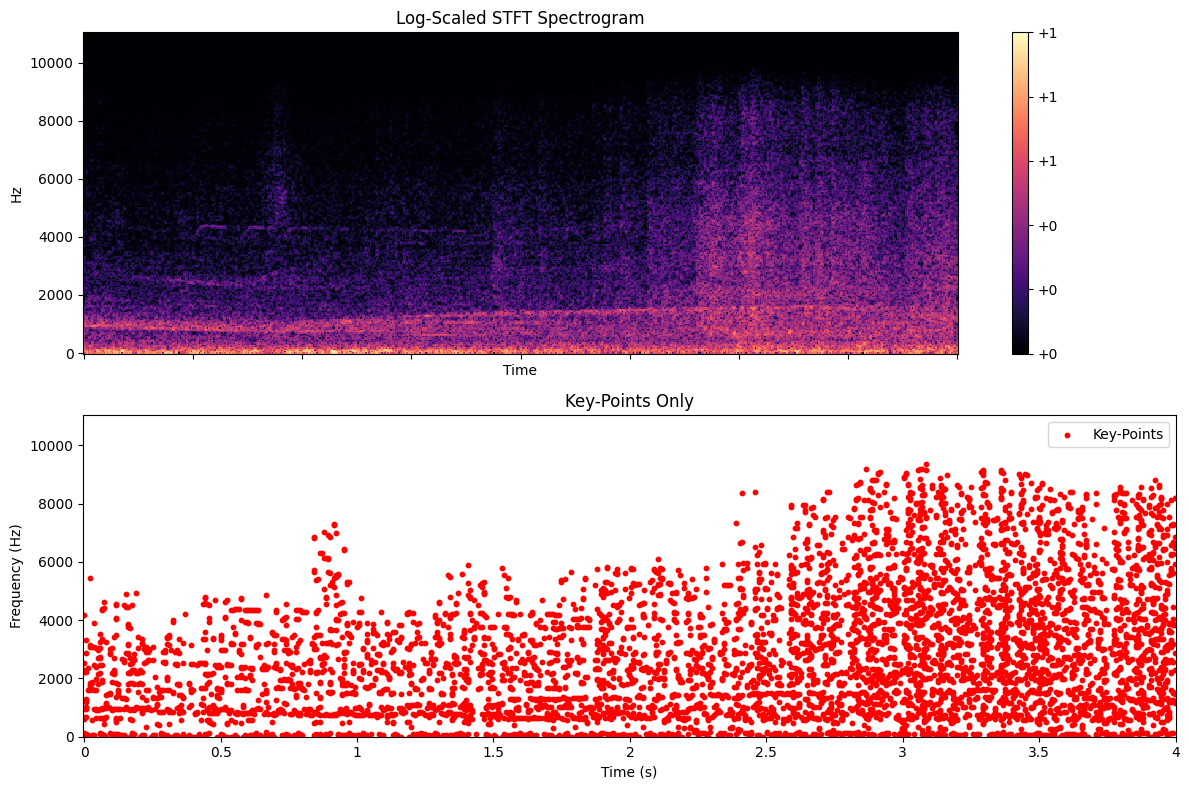

{'times': array([0.01451247, 0.07981859, 0.1015873 , ..., 3.06213152, 3.06938776,
        3.08390023]),
 'freqs': array([   0.        ,    0.        ,    0.        , ..., 9180.35019455,
        9180.35019455, 9351.94552529]),
 'freq_bins': array([  0,   0,   0, ..., 214, 214, 218]),
 'time_bins': array([  2,  11,  14, ..., 422, 423, 425]),
 'log_S': array([[5.8381039e-01, 5.6404239e-01, 7.8250134e-01, ..., 6.6759551e-01,
         5.9164912e-01, 6.8180823e-01],
        [6.5349281e-01, 7.5972480e-01, 7.7791625e-01, ..., 6.2068260e-01,
         5.1735318e-01, 6.4005309e-01],
        [6.9961017e-01, 7.3620993e-01, 7.1082157e-01, ..., 5.9893733e-01,
         6.2541914e-01, 5.7615829e-01],
        ...,
        [7.0231030e-04, 5.4870194e-05, 0.0000000e+00, ..., 0.0000000e+00,
         2.7301096e-04, 1.7418113e-02],
        [6.9730286e-04, 5.3318596e-05, 0.0000000e+00, ..., 7.0527243e-08,
         2.8140371e-04, 1.7415503e-02],
        [6.9568073e-04, 5.4305976e-05, 0.0000000e+00, ..., 7.05272

In [18]:
y, loaded_sr = librosa.load(f"{dataset_path}fold1/118279-8-0-3.wav", sr=sr, res_type="kaiser_fast")
# plot audio
plt.figure(figsize=(12, 4))
librosa.display.waveshow(y, sr=loaded_sr)
plt.title("Waveform of 118279-8-0-3.wav")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
process_audio(f"{dataset_path}fold1/118279-8-0-3.wav", plot=True)